# 1. Data Loading and First Look

In this section, the dataset is loaded from the CSV file and inspected at a high level.

The goals of this step are:
- load the dataset into a pandas DataFrame
- check the dataset size
- preview the first few rows
- generate an initial statistical summary

This provides a first understanding of the overall structure and scale of the login event data.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

df = pd.read_csv("rba-dataset.csv")

print("Shape:", df.shape)
display(df.head())

display(df.describe(include="all").T)

Shape: (31269264, 16)


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,31269264.0,NaN,NaN,NaN,15634631.5,9026659.138218,0.0,7817315.75,15634631.5,23451947.25,31269263.0
Login Timestamp,31269264,31269085,2020-04-09 14:18:00.041,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User ID,31269264.0,NaN,NaN,NaN,-1924042731664012800.0,4514276444091721216.0,-9223371191532285952.0,-4324475583306591744.0,-4324475583306591744.0,911981282976802304.0,9223358976525004800.0
Round-Trip Time [ms],1275935.0,NaN,NaN,NaN,663.933222,1116.125424,8.0,471.0,538.0,677.0,223457.0
IP Address,31269264,3512330,10.3.205.197,444433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,31269264,229,NO,13216996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,31221855,2638,-,14013381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,31260674,38885,-,13904552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN,31269264.0,NaN,NaN,NaN,162121.471884,171918.53614,12.0,29695.0,41164.0,393398.0,507727.0
User Agent String,31269264,420952,ZipppBot/0.11 (ZipppBot; https://github.com/da...,1543665,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Dataset Structure and Column Overview

This section examines the schema of the dataset, including column names, data types, and sample values from each column.

The purpose is to:
- understand the role of each feature
- inspect data types and non-null counts
- become familiar with the actual content stored in each column

This step is useful for identifying which columns describe users, time, network information, device information, and security-related labels.

In [11]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].head(10).tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31269264 entries, 0 to 31269263
Data columns (total 16 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   index                     int64  
 1   Login Timestamp           object 
 2   User ID                   int64  
 3   Round-Trip Time [ms]      float64
 4   IP Address                object 
 5   Country                   object 
 6   Region                    object 
 7   City                      object 
 8   ASN                       int64  
 9   User Agent String         object 
 10  Browser Name and Version  object 
 11  OS Name and Version       object 
 12  Device Type               object 
 13  Login Successful          bool   
 14  Is Attack IP              bool   
 15  Is Account Takeover       bool   
dtypes: bool(3), float64(1), int64(3), object(9)
memory usage: 3.1+ GB

Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'Ci

# 3. Data Quality and Cardinality Check

This section evaluates the overall quality and diversity of the dataset.

The analysis includes:
- missing values
- duplicate rows
- the number of unique values in each column

These checks help identify incomplete columns, redundant records, and high-cardinality features that may play an important role in Risk-Based Authentication.

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print("Missing values:")
display(missing_df[missing_df["missing_count"] > 0])

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique values per column:")
nunique_df = df.nunique().sort_values(ascending=False)
display(nunique_df)

Missing values:


,missing_count,missing_pct
Round-Trip Time [ms],29993329,95.919523
Region,47409,0.151615
City,8590,0.027471
Device Type,1526,0.004880


Duplicate rows: 0

Unique values per column:


index                       31269264
Login Timestamp             31269085
User ID                      4304857
IP Address                   3512330
User Agent String             420952
City                           38885
ASN                            12955
Round-Trip Time [ms]            9113
Browser Name and Version        4549
Region                          2638
OS Name and Version              653
Country                          229
Device Type                        5
Login Successful                   2
Is Attack IP                       2
Is Account Takeover                2
dtype: int64

# 4. Label Distribution Analysis

This section examines the three security-related label columns in the dataset:

- `Login Successful`
- `Is Attack IP`
- `Is Account Takeover`

The goal is to understand:
- how these labels are distributed
- whether the classes are balanced or imbalanced
- whether the dataset is challenging from a security modeling perspective

This step is important because highly imbalanced labels may affect both interpretation and downstream modeling.

In [13]:
label_cols = ["Login Successful", "Is Attack IP", "Is Account Takeover"]

for col in label_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False))


=== Login Successful ===
Login Successful
False    18727822
True     12541442
Name: count, dtype: int64
Login Successful
False    0.598921
True     0.401079
Name: proportion, dtype: float64

=== Is Attack IP ===
Is Attack IP
False    28172287
True      3096977
Name: count, dtype: int64
Is Attack IP
False    0.900958
True     0.099042
Name: proportion, dtype: float64

=== Is Account Takeover ===
Is Account Takeover
False    31269123
True          141
Name: count, dtype: int64
Is Account Takeover
False    0.999995
True     0.000005
Name: proportion, dtype: float64


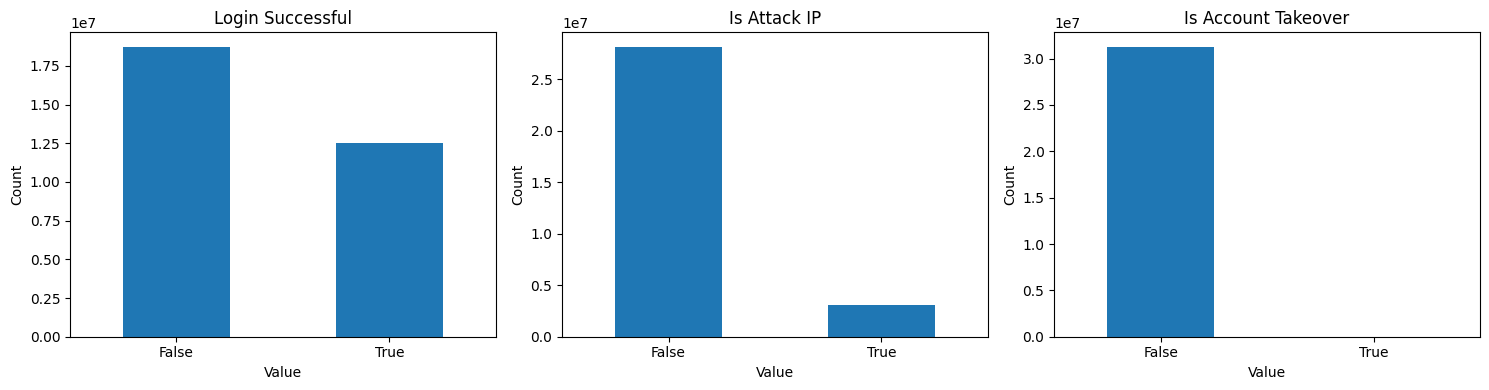

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(label_cols):
    counts = df[col].value_counts()
    counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# 5. Temporal Analysis

Time is one of the most important contextual dimensions in Risk-Based Authentication.

In this section, the login timestamp is converted into a datetime format and then decomposed into several time-based features such as:
- date
- hour
- day of week
- month

This allows us to explore how login behavior changes over time and whether attack-related events show temporal patterns.

In [15]:
df["Login Timestamp"] = pd.to_datetime(df["Login Timestamp"], errors="coerce")

df["login_date"] = df["Login Timestamp"].dt.date
df["year"] = df["Login Timestamp"].dt.year
df["month"] = df["Login Timestamp"].dt.month
df["day"] = df["Login Timestamp"].dt.day
df["hour"] = df["Login Timestamp"].dt.hour
df["dayofweek"] = df["Login Timestamp"].dt.dayofweek

dow_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}
df["dayofweek_name"] = df["dayofweek"].map(dow_map)

print("Timestamp dtype:", df["Login Timestamp"].dtype)
print("Null after parsing:", df["Login Timestamp"].isna().sum())
print("Time range:", df["Login Timestamp"].min(), "to", df["Login Timestamp"].max())

Timestamp dtype: datetime64[ns]
Null after parsing: 0
Time range: 2020-02-03 12:43:30.772000 to 2021-02-28 23:59:58.756000


## 5.1 Logins by Hour

This plot shows how login activity is distributed across the 24 hours of the day.

It helps identify:
- peak login periods
- off-peak periods
- possible abnormal activity outside typical hours

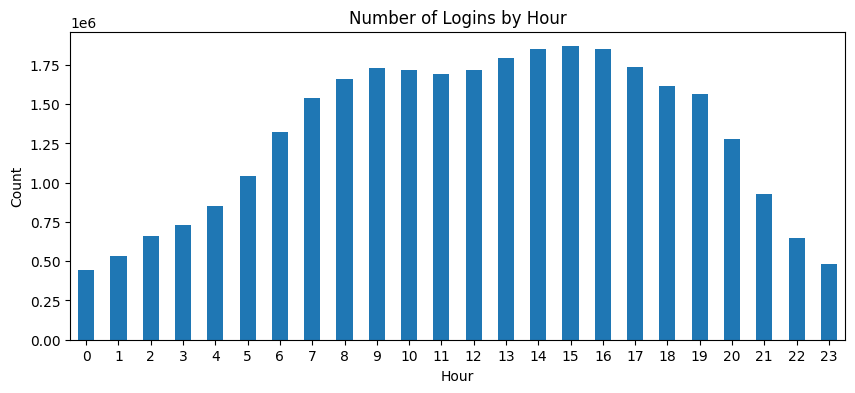

In [16]:
hour_counts = df["hour"].value_counts().sort_index()

hour_counts.plot(kind="bar", figsize=(10, 4))
plt.title("Number of Logins by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 5.2 Logins by Day of Week

This analysis shows whether login activity differs across weekdays and weekends.

In many real systems, weekday and weekend behavior may differ significantly, which is useful in risk evaluation.

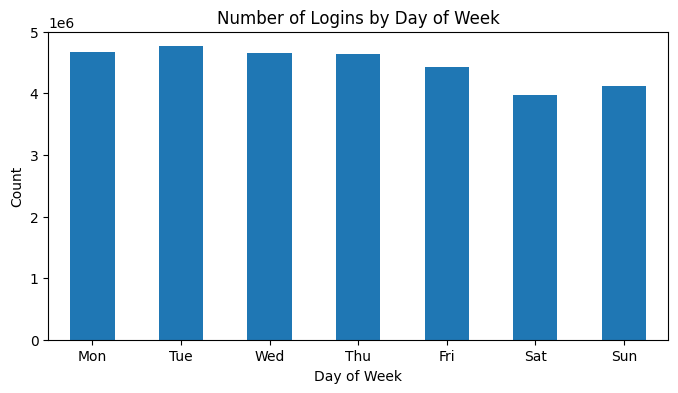

In [17]:
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_counts = df["dayofweek_name"].value_counts().reindex(dow_order)

dow_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Number of Logins by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 5.3 Daily Login Volume

The following figure shows how login volume changes over time on a daily basis.

This helps reveal:
- large-scale trends
- spikes in activity
- periods of lower activity

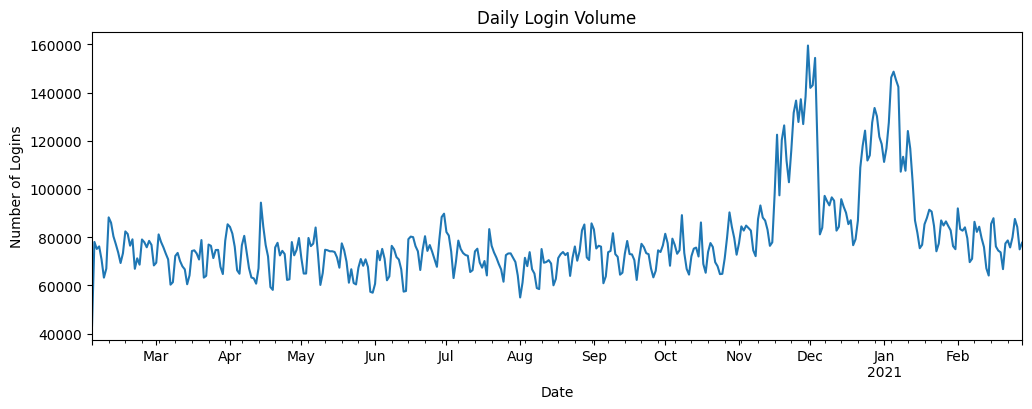

In [18]:
daily_logins = df.set_index("Login Timestamp").resample("D").size()

daily_logins.plot(figsize=(12, 4))
plt.title("Daily Login Volume")
plt.xlabel("Date")
plt.ylabel("Number of Logins")
plt.show()

## 5.4 Monthly Login Volume

Monthly aggregation provides a cleaner and more compact view of long-term login behavior.

/tmp/ipykernel_2378108/4188333649.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_logins = df.set_index("Login Timestamp").resample("M").size()


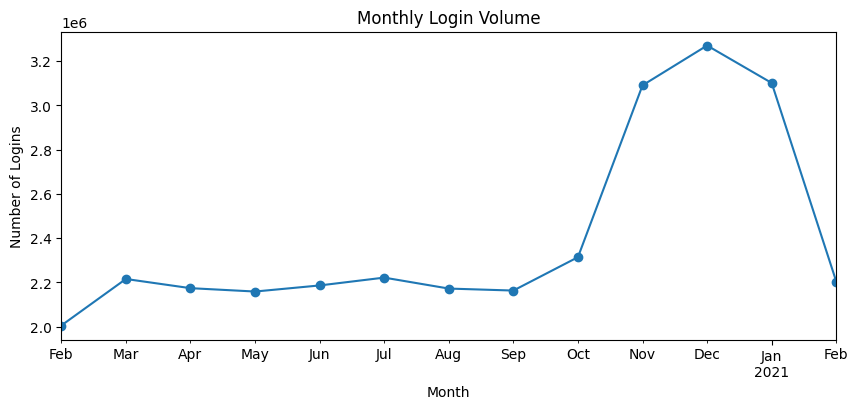

In [19]:
monthly_logins = df.set_index("Login Timestamp").resample("M").size()

monthly_logins.plot(marker="o", figsize=(10, 4))
plt.title("Monthly Login Volume")
plt.xlabel("Month")
plt.ylabel("Number of Logins")
plt.show()

## 5.5 Success Rate by Hour

This plot focuses on the proportion of successful logins at each hour rather than only the total number of events.

This can reveal whether some hours are associated with higher failure rates.

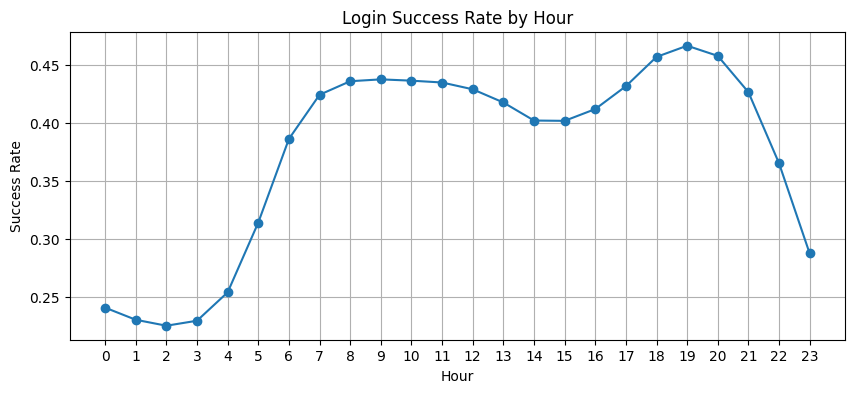

In [20]:
hourly_success_rate = df.groupby("hour")["Login Successful"].mean()

hourly_success_rate.plot(marker="o", figsize=(10, 4))
plt.title("Login Success Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Success Rate")
plt.xticks(range(24))
plt.grid(True)
plt.show()

## 5.6 Attack IP Ratio by Hour

This figure shows the proportion of login events originating from attack IPs at each hour of the day.

Temporal patterns in attack-related traffic may support risk scoring strategies.

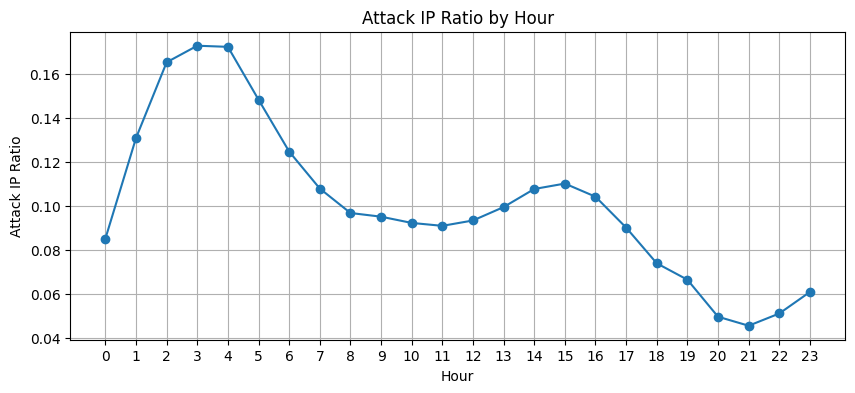

In [21]:
attack_by_hour = df.groupby("hour")["Is Attack IP"].mean()

attack_by_hour.plot(marker="o", figsize=(10, 4))
plt.title("Attack IP Ratio by Hour")
plt.xlabel("Hour")
plt.ylabel("Attack IP Ratio")
plt.xticks(range(24))
plt.grid(True)
plt.show()

# 6. Geographic and Network Analysis

This section explores the geographic and network-related dimensions of the login events.

The analysis focuses on:
- country
- region
- city
- ASN

These features are highly relevant in Risk-Based Authentication because a login from an unusual country, city, or network may indicate elevated risk.

## 6.1 Top Countries

This plot shows the countries with the highest number of login events.

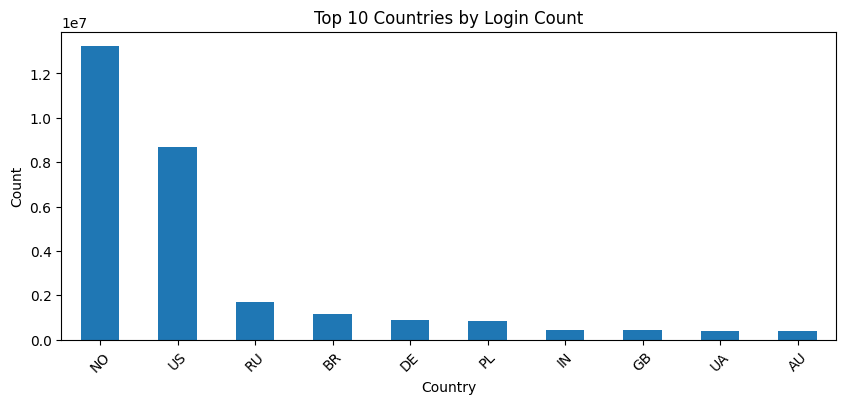

Country
NO    13216996
US     8685928
RU     1693250
BR     1181101
DE      897458
PL      854725
IN      438456
GB      422387
UA      406581
AU      392935
Name: count, dtype: int64

In [22]:
top_countries = df["Country"].value_counts().head(10)

top_countries.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Countries by Login Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

display(top_countries)

## 6.2 Top Regions

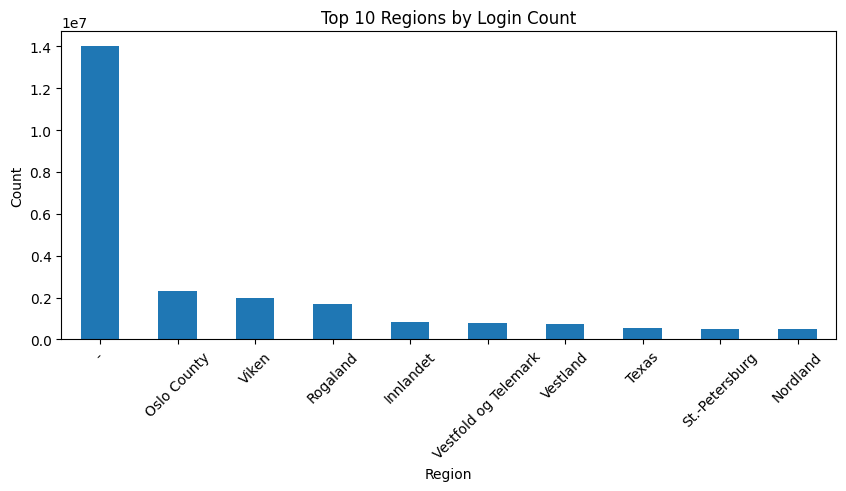

Region
-                       14013381
Oslo County              2314071
Viken                    1994024
Rogaland                 1713780
Innlandet                 834122
Vestfold og Telemark      774068
Vestland                  750213
Texas                     527892
St.-Petersburg            516982
Nordland                  478630
Name: count, dtype: int64

In [23]:
top_regions = df["Region"].value_counts().head(10)

top_regions.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Regions by Login Count")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

display(top_regions)

## 6.3 Top Cities

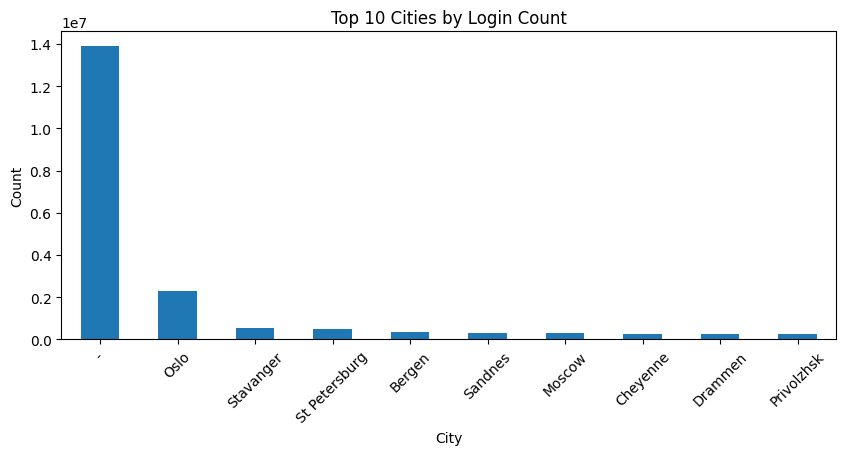

City
-                13904552
Oslo              2308651
Stavanger          526800
St Petersburg      516977
Bergen             341021
Sandnes            303037
Moscow             297120
Cheyenne           260865
Drammen            258915
Privolzhsk         257343
Name: count, dtype: int64

In [24]:
top_cities = df["City"].value_counts().head(10)

top_cities.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Cities by Login Count")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

display(top_cities)

## 6.4 Top ASNs

Autonomous System Numbers represent network providers or infrastructures.  
They can be useful for identifying repeated login behavior from specific networks.

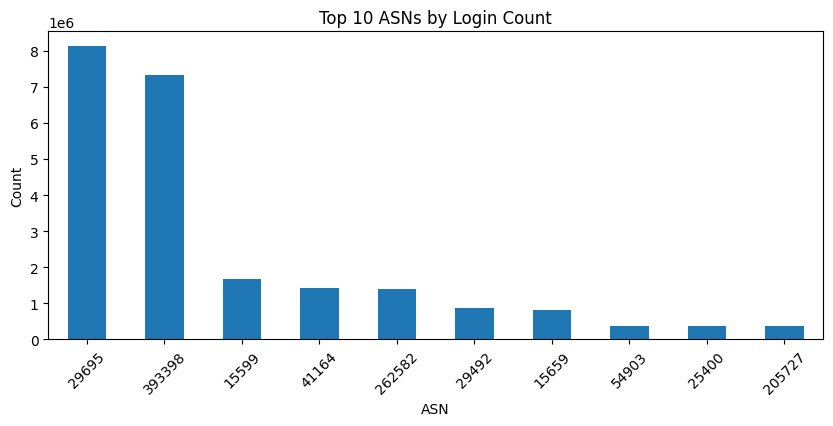

ASN
29695     8130723
393398    7328495
15599     1663304
41164     1437288
262582    1397183
29492      871025
15659      818139
54903      370979
25400      363881
205727     360112
Name: count, dtype: int64

In [25]:
top_asn = df["ASN"].value_counts().head(10)

top_asn.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 ASNs by Login Count")
plt.xlabel("ASN")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

display(top_asn)

## 6.5 Attack IP Ratio by Country

This comparison highlights whether some countries are associated with higher proportions of attack IP activity.

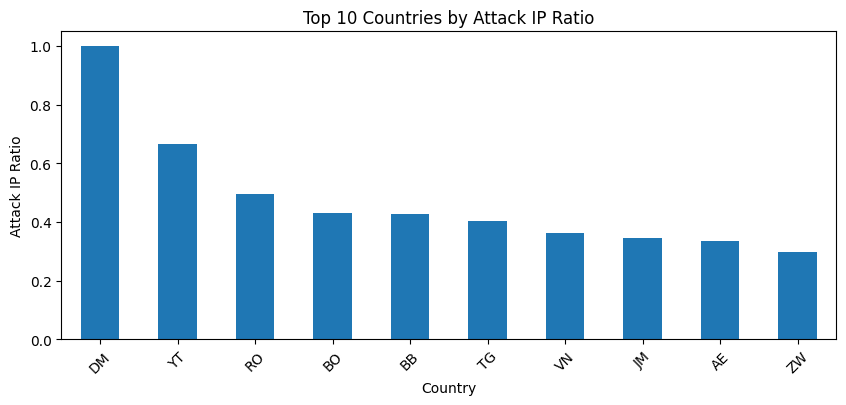

Country
DM    1.000000
YT    0.666667
RO    0.496376
BO    0.432182
BB    0.427586
TG    0.402299
VN    0.361077
JM    0.347032
AE    0.335054
ZW    0.298622
Name: Is Attack IP, dtype: float64

In [26]:
country_attack_ratio = df.groupby("Country")["Is Attack IP"].mean().sort_values(ascending=False).head(10)

country_attack_ratio.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Countries by Attack IP Ratio")
plt.xlabel("Country")
plt.ylabel("Attack IP Ratio")
plt.xticks(rotation=45)
plt.show()

display(country_attack_ratio)

# 7. Device and Software Analysis

This section examines the technological environment of each login event.

The features considered here include:
- device type
- browser name and version
- operating system name and version
- user agent string

These features are important because unfamiliar devices, browsers, or operating systems may represent unusual login behavior.

## 7.1 Device Type Distribution

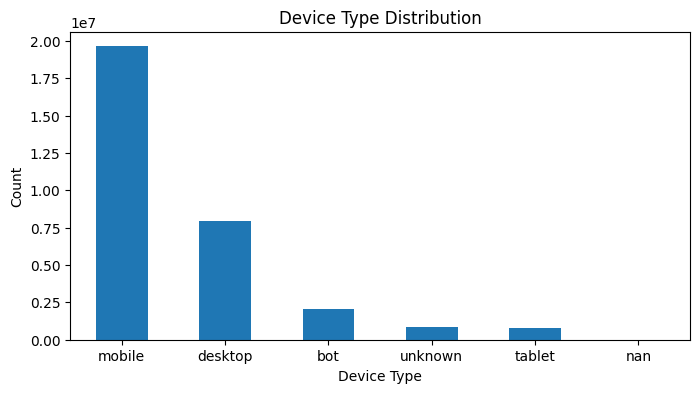

Device Type
mobile     19642650
desktop     7934515
bot         2027834
unknown      867371
tablet       795368
NaN            1526
Name: count, dtype: int64

In [27]:
device_counts = df["Device Type"].value_counts(dropna=False)

device_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

display(device_counts)

## 7.2 Top Browsers

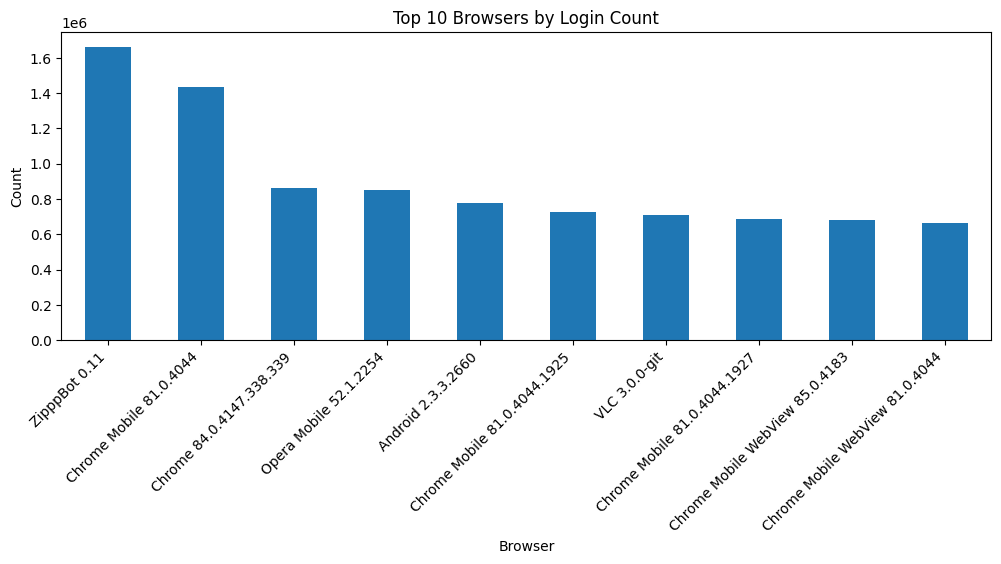

Browser Name and Version
ZipppBot 0.11                      1662964
Chrome Mobile 81.0.4044            1434241
Chrome 84.0.4147.338.339            864307
Opera Mobile 52.1.2254              850696
Android 2.3.3.2660                  778018
Chrome Mobile 81.0.4044.1925        728650
VLC 3.0.0-git                       708927
Chrome Mobile 81.0.4044.1927        687886
Chrome Mobile WebView 85.0.4183     681310
Chrome Mobile WebView 81.0.4044     665104
Name: count, dtype: int64

In [28]:
top_browsers = df["Browser Name and Version"].value_counts().head(10)

top_browsers.plot(kind="bar", figsize=(12, 4))
plt.title("Top 10 Browsers by Login Count")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

display(top_browsers)

## 7.3 Top Operating Systems

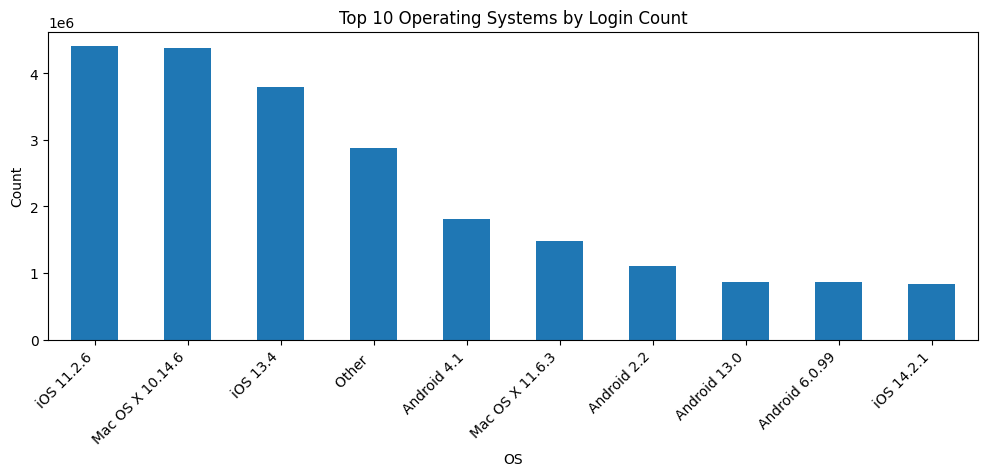

OS Name and Version
iOS 11.2.6          4406409
Mac OS X 10.14.6    4387221
iOS 13.4            3797427
Other               2883889
Android 4.1         1804833
Mac OS X 11.6.3     1484511
Android 2.2         1098129
Android 13.0         870800
Android 6.0.99       859770
iOS 14.2.1           836973
Name: count, dtype: int64

In [29]:
top_os = df["OS Name and Version"].value_counts().head(10)

top_os.plot(kind="bar", figsize=(12, 4))
plt.title("Top 10 Operating Systems by Login Count")
plt.xlabel("OS")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

display(top_os)

## 7.4 Login Success Rate by Device Type

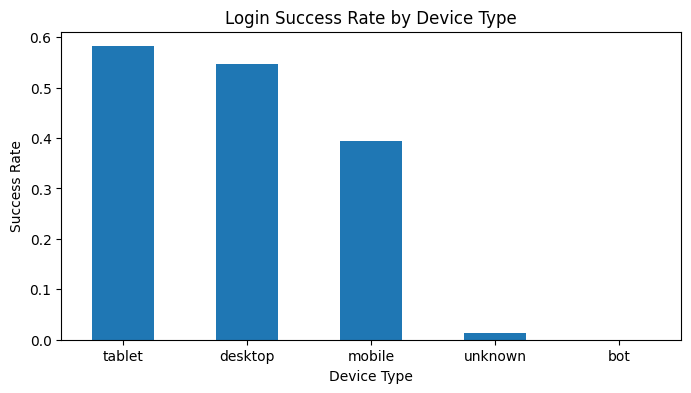

Device Type
tablet     0.581566
desktop    0.546709
mobile     0.393514
unknown    0.012947
bot        0.000032
Name: Login Successful, dtype: float64

In [30]:
device_success_rate = df.groupby("Device Type")["Login Successful"].mean().sort_values(ascending=False)

device_success_rate.plot(kind="bar", figsize=(8, 4))
plt.title("Login Success Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Success Rate")
plt.xticks(rotation=0)
plt.show()

display(device_success_rate)

## 7.5 Attack IP Ratio by Device Type

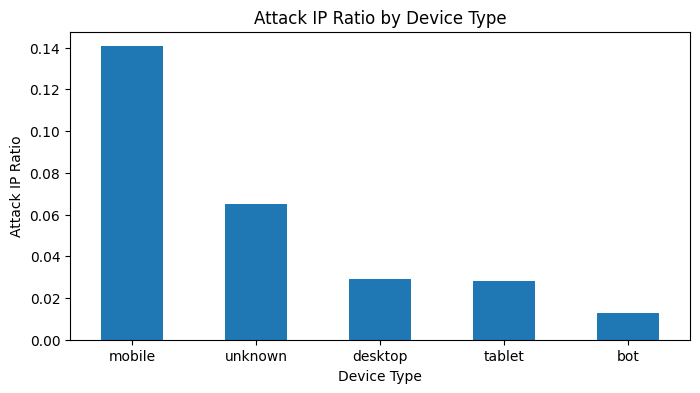

Device Type
mobile     0.140606
unknown    0.064917
desktop    0.028984
tablet     0.028277
bot        0.012740
Name: Is Attack IP, dtype: float64

In [31]:
device_attack_ratio = df.groupby("Device Type")["Is Attack IP"].mean().sort_values(ascending=False)

device_attack_ratio.plot(kind="bar", figsize=(8, 4))
plt.title("Attack IP Ratio by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Attack IP Ratio")
plt.xticks(rotation=0)
plt.show()

display(device_attack_ratio)

# 8. User-Level Behavior Analysis

Risk-Based Authentication is not only about global patterns.  
It is also about understanding what is normal for each individual user.

This section analyzes user-level behavior by examining:
- number of logins per user
- diversity of IP addresses per user
- diversity of countries per user
- diversity of ASNs per user

These indicators help characterize how stable or variable a user's login behavior is.

## 8.1 Number of Logins per User

In [32]:
user_login_counts = df["User ID"].value_counts()

print(user_login_counts.describe())

count    4.304857e+06
mean     7.263717e+00
std      6.760161e+03
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      1.402590e+07
Name: count, dtype: float64


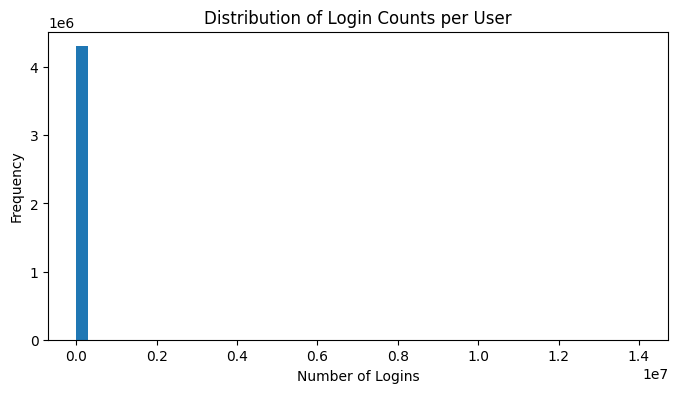

In [33]:
user_login_counts.plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of Login Counts per User")
plt.xlabel("Number of Logins")
plt.ylabel("Frequency")
plt.show()

## 8.2 Unique IP Addresses per User

In [34]:
user_ip_diversity = df.groupby("User ID")["IP Address"].nunique()

print(user_ip_diversity.describe())

count    4.304857e+06
mean     2.663759e+00
std      9.869497e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      2.047733e+06
Name: IP Address, dtype: float64


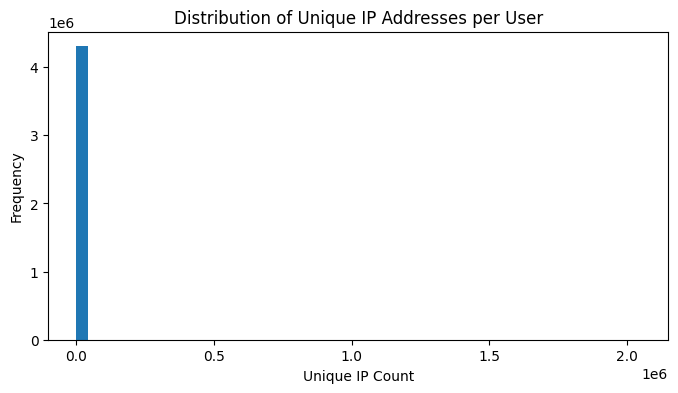

In [35]:
user_ip_diversity.plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of Unique IP Addresses per User")
plt.xlabel("Unique IP Count")
plt.ylabel("Frequency")
plt.show()

## 8.3 Unique Countries per User

In [36]:
user_country_diversity = df.groupby("User ID")["Country"].nunique()

print(user_country_diversity.describe())

count    4.304857e+06
mean     1.019824e+00
std      1.891674e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.270000e+02
Name: Country, dtype: float64


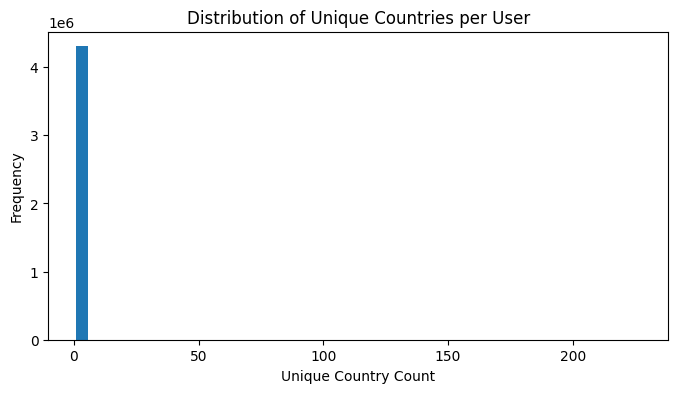

In [37]:
user_country_diversity.plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of Unique Countries per User")
plt.xlabel("Unique Country Count")
plt.ylabel("Frequency")
plt.show()

## 8.4 Unique ASNs per User

In [38]:
user_asn_diversity = df.groupby("User ID")["ASN"].nunique()

print(user_asn_diversity.describe())

count    4.304857e+06
mean     1.277523e+00
std      5.667695e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.169400e+04
Name: ASN, dtype: float64


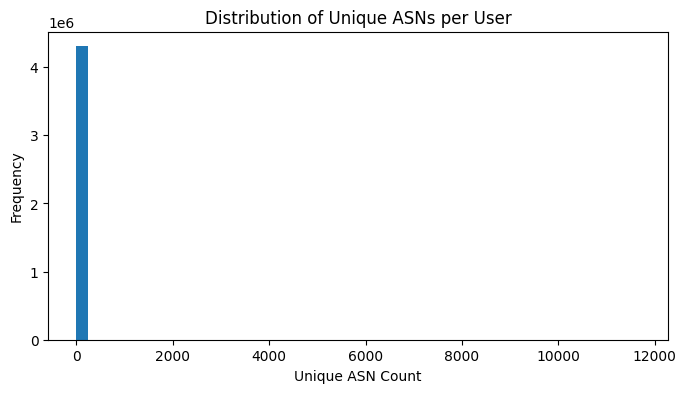

In [39]:
user_asn_diversity.plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of Unique ASNs per User")
plt.xlabel("Unique ASN Count")
plt.ylabel("Frequency")
plt.show()

## 8.5 Most Active Users

In [40]:
display(user_login_counts.head(10))

User ID
-4324475583306591935    14025899
 6998943612473066845       70028
-7198559811247368245        6417
-4652302824165996131        1927
-2894367365566592989        1613
-3031272205102765641        1537
 4588325308801696666        1510
 9009909461743844032        1475
-7955135358862007287        1423
 8306338755768072775        1367
Name: count, dtype: int64

# 9. Security-Oriented Comparison

This section compares suspicious and non-suspicious events more directly.

The main goal is to understand whether attack-related events differ from normal events in terms of:
- success rate
- time patterns
- geography
- devices
- account takeover occurrence

## 9.1 Crosstab Between Security Labels

In [41]:
print("Login Successful vs Is Attack IP")
display(pd.crosstab(df["Login Successful"], df["Is Attack IP"]))

print("Login Successful vs Is Account Takeover")
display(pd.crosstab(df["Login Successful"], df["Is Account Takeover"]))

print("Is Attack IP vs Is Account Takeover")
display(pd.crosstab(df["Is Attack IP"], df["Is Account Takeover"]))

Login Successful vs Is Attack IP


Is Attack IP,False,True
Login Successful,,
False,16435336,2292486
True,11736951,804491


Login Successful vs Is Account Takeover


Is Account Takeover,False,True
Login Successful,,
False,18727821,1
True,12541302,140


Is Attack IP vs Is Account Takeover


Is Account Takeover,False,True
Is Attack IP,,
False,28172223,64
True,3096900,77


## 9.2 All Label Combinations

In [42]:
combo_counts = df[["Login Successful", "Is Attack IP", "Is Account Takeover"]].value_counts()
display(combo_counts)

Login Successful  Is Attack IP  Is Account Takeover
False             False         False                  16435336
True              False         False                  11736887
False             True          False                   2292485
True              True          False                    804415
                                True                         76
                  False         True                         64
False             True          True                          1
Name: count, dtype: int64

## 9.3 Success Rate for Attack vs Non-Attack IPs

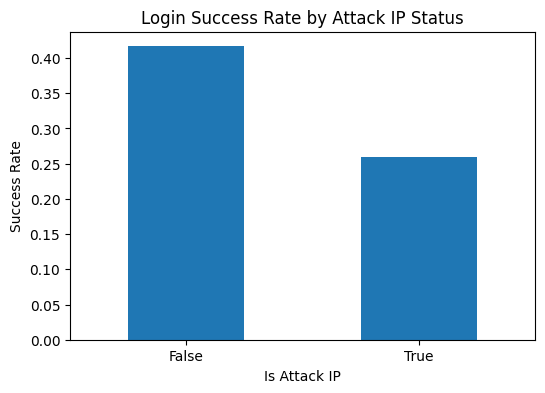

Is Attack IP
False    0.416613
True     0.259767
Name: Login Successful, dtype: float64

In [43]:
attack_success_compare = df.groupby("Is Attack IP")["Login Successful"].mean()

attack_success_compare.plot(kind="bar", figsize=(6, 4))
plt.title("Login Success Rate by Attack IP Status")
plt.xlabel("Is Attack IP")
plt.ylabel("Success Rate")
plt.xticks(rotation=0)
plt.show()

display(attack_success_compare)

## 9.4 Device Type Comparison for Attack IPs

In [44]:
attack_device_dist = pd.crosstab(df["Device Type"], df["Is Attack IP"], normalize="columns")
display(attack_device_dist)

Is Attack IP,False,True
Device Type,,
bot,0.071065,0.008343
desktop,0.273489,0.074269
mobile,0.599220,0.891940
tablet,0.027435,0.007263
unknown,0.028790,0.018184


## 9.5 Country Comparison for Attack IPs

In [45]:
attack_country_dist = pd.crosstab(df["Country"], df["Is Attack IP"], normalize="columns")
display(attack_country_dist.head(20))

Is Attack IP,False,True
Country,,
AE,5.487662e-05,0.000252
AF,7.198564e-05,0.000085
AG,8.554506e-06,0.000000
AI,1.384339e-06,0.000000
AL,8.288287e-05,0.000180
AM,6.495745e-05,0.000178
AO,8.100159e-05,0.000001
AQ,9.228928e-07,0.000000
AR,4.578223e-03,0.001364


## 9.6 Rare Account Takeover Cases

Because account takeover events are extremely rare, it is useful to inspect them separately.

In [46]:
takeover_df = df[df["Is Account Takeover"] == True].copy()

print("Number of account takeover cases:", len(takeover_df))
display(takeover_df.head())

Number of account takeover cases: 141


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,login_date,year,month,day,hour,dayofweek,dayofweek_name
82873,82873,2020-02-04 13:45:50.280,5519106287451092780,NaN,10.4.1.162,IT,Provincia di Treviso,Treviso,503109,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.218,Mac OS X 10.14.6,desktop,True,False,True,2020-02-04,2020,2,4,13,1,Tue
82947,82947,2020-02-04 13:46:45.241,-7654599524478640403,NaN,10.4.1.162,IT,Provincia di Treviso,Treviso,503109,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.218,Mac OS X 10.14.6,desktop,True,False,True,2020-02-04,2020,2,4,13,1,Tue
100085,100085,2020-02-04 17:15:42.743,-6380256063165146454,NaN,31.131.16.24,RO,-,-,56851,Mozilla/5.0 (X11; CrOS armv7l 5978.98.0) Appl...,Chrome 71.0.3578.40.50,Chrome OS 5978.98.0,desktop,True,True,True,2020-02-04,2020,2,4,17,1,Tue
202905,202905,2020-02-06 05:19:28.841,4130074439166519892,NaN,185.170.136.4,IT,Veneto,Sospirolo,206801,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,True,False,True,2020-02-06,2020,2,6,5,3,Thu
273968,273968,2020-02-07 01:25:57.399,-136955930917892295,NaN,10.0.85.13,NO,Vestland,Vassenden,197475,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.203,Mac OS X 10.14.6,desktop,True,False,True,2020-02-07,2020,2,7,1,4,Fri


In [47]:
if len(takeover_df) > 0:
    print("Takeover by Login Successful")
    display(takeover_df["Login Successful"].value_counts(dropna=False))
    
    print("Takeover by Is Attack IP")
    display(takeover_df["Is Attack IP"].value_counts(dropna=False))
    
    print("Takeover by Country")
    display(takeover_df["Country"].value_counts().head(10))

Takeover by Login Successful


Login Successful
True     140
False      1
Name: count, dtype: int64

Takeover by Is Attack IP


Is Attack IP
True     77
False    64
Name: count, dtype: int64

Takeover by Country


Country
RO    79
NO    10
BR     9
ID     9
CA     9
IT     7
DK     5
LV     3
CL     3
CZ     2
Name: count, dtype: int64